# Exploratory Data Analysis

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path
from typing import List
import os

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

Settings to standardize plots exports.

In [2]:
from src.viz.style import (
    apply_style, latex_safe, add_bar_labels,
    PALETTE, COLOR_PRIMARY, COLOR_ACCENT, COLOR_GOOD, COLOR_BAD,
    FIGSIZE_SINGLE, FIGSIZE_WIDE, FIGSIZE_TALL,
)
apply_style()

In [3]:
DATA = ROOT / "data"
INTERIM_DATA = DATA / "interim"
PROCESSED_DATA = DATA / "processed"
REPORT_EDA = ROOT / "reports" / "eda"

os.makedirs(PROCESSED_DATA, exist_ok=True)
os.makedirs(REPORT_EDA, exist_ok=True)

## 1. EDA

### Phase 1.1. Dataset overview and sanity check


**Flow: Shape → Types → Missingness → Duplicates**

* **1. Shape & Types:**
* **Action:** Run `.info()` and `.shape`. Ensure numeric features (`price_vnd`, `mileage_km`, `seats`, `doors`, `year`) are actually `float` or `int`, not `object`.
* **Model Check:** If any numeric feature is parsed as a string, XGBoost and SVM will instantly crash.


* **2. Missingness Map:**
* **Action:** Use `missingno.matrix()` or calculate percentage missing per column.
* **Model Check:** Linear Regression and SVM **cannot** handle missing data. You must decide in EDA if you will impute them (e.g., median for numerical, mode for categorical) or drop the rows. (XGBoost can handle NaNs internally, but explicit imputation is industry standard).


* **3. Duplicates & Keys:**
* **Action:** Check for duplicated `id`s and duplicated rows across all features.
* **Model Check:** Duplicates inflate the confidence of Random Forest and XGBoost, leading to overly optimistic cross-validation scores.

In [4]:
INPUT_FILE = INTERIM_DATA / "ev_eda_ready.csv"
INPUT_FILE

WindowsPath('C:/Users/dduya/Work/project/ev_car/data/interim/ev_eda_ready.csv')

In [5]:
df = pd.read_csv(INPUT_FILE)

Successfully loaded the dataset. Let's check this dataset health before we do the analysis.

I use a wrapper function to generate a comprehensive health report of the dataframe.
It includes the datatypes, total missing values, percentage of missing values, and unique
values per column. This allows me to quickly identify any issues with the dataset before
diving into the analysis.

In [6]:
def generate_health_report(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Generates a comprehensive summary report of the dataframe containing:
    dtypes, missing values, missing percentage, and unique values per column.
    """
    report = pd.DataFrame({
        'Data Type': dataframe.dtypes,
        'Total Missing': dataframe.isna().sum(),
        'Missing %': (dataframe.isna().sum() / len(dataframe) * 100).round(2),
        'Unique Values': dataframe.nunique()
    })
    return report.sort_values(by='Missing %', ascending=False)

In [7]:
generate_health_report(df)

,Data Type,Total Missing,Missing %,Unique Values
condition,str,462,11.63,2
mileage_km,float64,268,6.74,373
exterior_color,str,192,4.83,27
year,float64,67,1.69,9
brand,str,27,0.68,20
price_vnd,float64,2,0.05,1024
id,int64,0,0.00,3974
base_model,str,0,0.00,69
body_type,str,0,0.00,7
has_aftermarket_mods,bool,0,0.00,2


Next let's check the duplication in the dataset.

In [8]:
duplicate_ids = df['id'].duplicated().sum()
duplicate_rows = df.duplicated().sum()
duplicate_ids, duplicate_rows

(np.int64(0), np.int64(0))

Let's check the sparsity of the dataset.

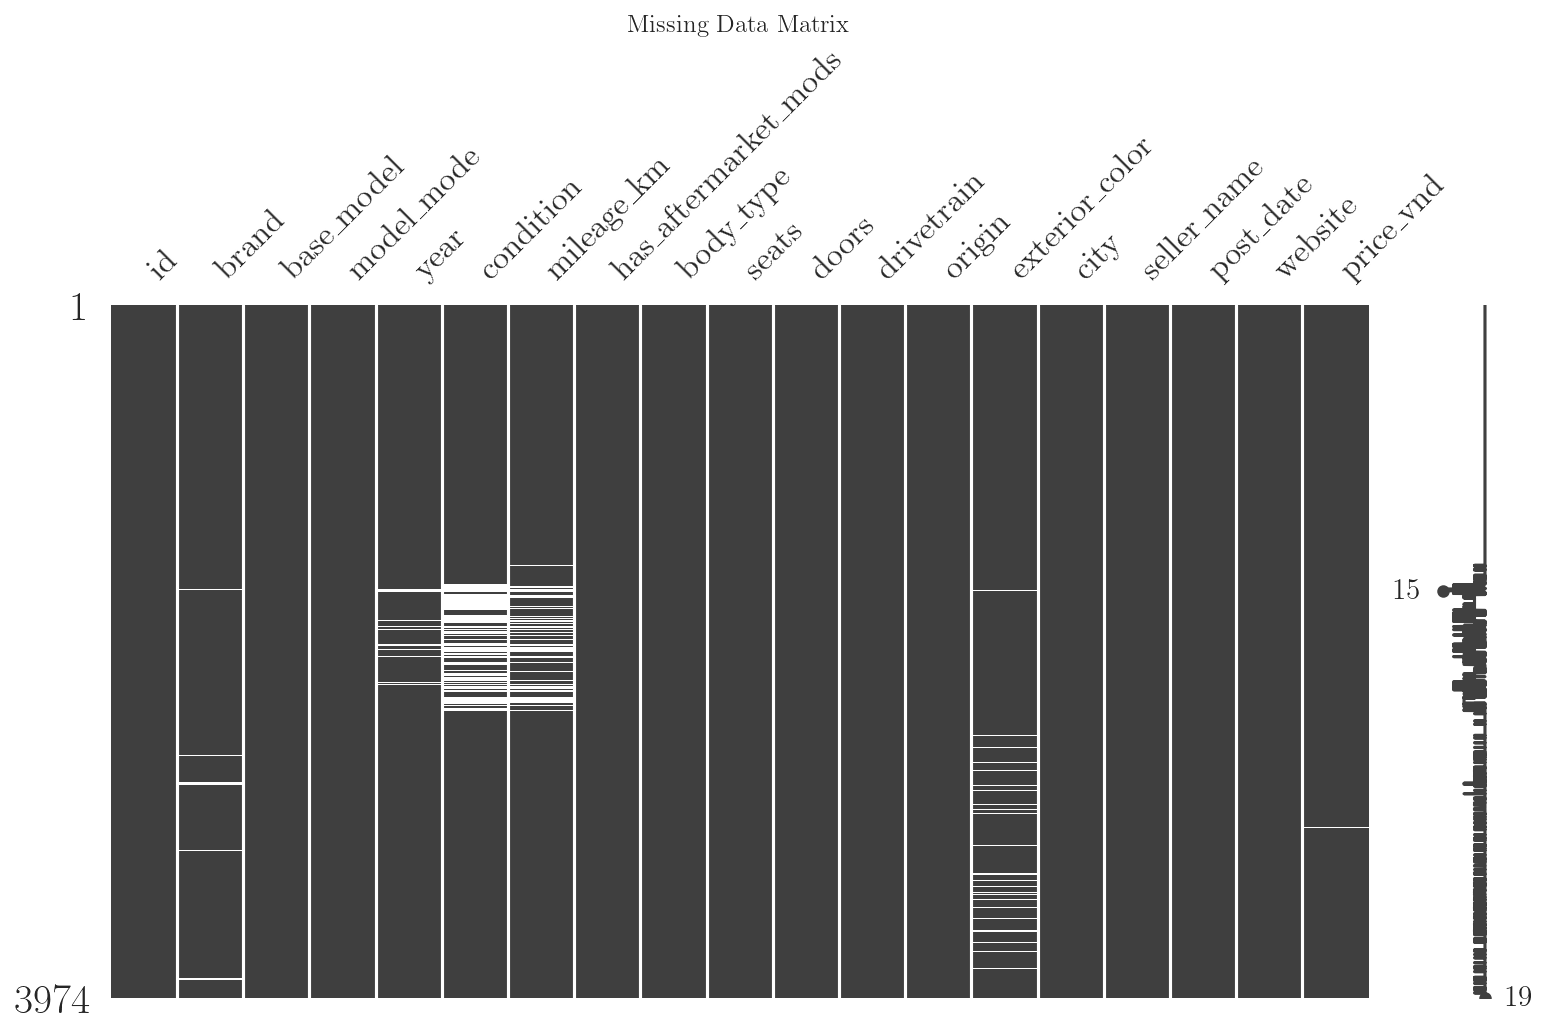

In [9]:
msno.matrix(df, figsize=(12, 6))
plt.title("Missing Data Matrix")
plt.savefig(REPORT_EDA / "missing_data_matrix.pdf", bbox_inches='tight', format='pdf')

In [10]:
def extract_missingness_stats(dataframe: pd.DataFrame) -> None:
    """Generates a text-friendly report on dataset sparsity and patterns."""
    total_rows = len(dataframe)
    missing_data = dataframe.isnull().sum()
    missing_pct = (missing_data / total_rows) * 100

    report = pd.DataFrame({
        'Missing Count': missing_data,
        'Missing Percentage': missing_pct.round(4)
    }).sort_values(by='Missing Percentage', ascending=False)

    report = report[report['Missing Count'] > 0]

    if report.empty:
        print("No missing data found in the current dataframe.")
    else:
        print(report.to_string())

    print("\nCorrelation of Missingness (Sparsity Link)")
    ms_corr = dataframe.isnull().corr()
    high_ms_corr = []
    for i in range(len(ms_corr.columns)):
        for j in range(i + 1, len(ms_corr.columns)):
            if ms_corr.iloc[i, j] > 0.8:
                high_ms_corr.append(f"{ms_corr.columns[i]} <-> {ms_corr.columns[j]}: {ms_corr.iloc[i, j]:.2f}")

    if high_ms_corr:
        print("Features that tend to be missing at the same time:")
        for pair in high_ms_corr:
            print(f"{pair}")
    else:
        print("No strong missingness patterns detected (Data appears scattered).")

In [11]:
extract_missingness_stats(df)

                Missing Count  Missing Percentage
condition                 462             11.6256
mileage_km                268              6.7438
exterior_color            192              4.8314
year                       67              1.6860
brand                      27              0.6794
price_vnd                   2              0.0503

Correlation of Missingness (Sparsity Link)
No strong missingness patterns detected (Data appears scattered).


## Phase 1.2. Target integrity and leakage scan

Flow: Target sanity → Leakage scan

* 1. Target Sanity (`price_vnd`):
* Action: Plot a histogram of `price_vnd`. Check the minimum and maximum values. Are there any cars priced at 0 VND or 100 billion VND?
* Model Check: Car prices are heavily right-skewed. Linear Regression and SVM perform terribly on skewed targets. * Phase 2 Backlog: If skewed, plan to apply a `np.log1p()` transformation to the target variable before modeling.


* 2. Data Leakage Scan:
* Action: Review all columns to ensure they don't contain information from the *future* (after the car is priced).
* Model Check: Columns like `id`, `seller_name`, `website`, or `post_date` do not predict the intrinsic value of a car. Including them will cause the models to learn noise (e.g., "Seller X always sells expensive cars").
* Phase 2 Backlog: Plan to drop these identifier/leakage columns before feeding data to the algorithms.


Next, let's do the sanity check on the target variable `price_vnd` - the most important variable in the dataset.

In [12]:
def extract_plot_stats(dataframe: pd.DataFrame, target_cols: list) -> None:
    print("Plot data extraction")
    for col in target_cols:
        print(f"\nFeature: {col}")
        if pd.api.types.is_numeric_dtype(dataframe[col]):
            stats = dataframe[col].describe().apply(lambda x: format(x, 'f'))
            print(stats.to_string())
            print(f"Skewness: {dataframe[col].skew():.2f}")
        else:
            print(dataframe[col].value_counts(dropna=False).head(10).to_string())

In [13]:
def analyze_target_distribution(dataframe: pd.DataFrame, target_col: str) -> None:
    """Plots the distribution of the target variable and calculates skewness.

    1. Histogram with KDE to visualize the distribution and identify skewness.
    2. Boxplot to detect extreme outliers that may affect model performance.
    """
    target = dataframe[target_col].dropna()
    skewness = target.skew()

    fig, axes = plt.subplots(2, 1, figsize=(5, 8))

    sns.histplot(target, kde=True, ax=axes[0], bins=50)
    axes[0].set_title(f"Distribution of {target_col}\nSkewness: {skewness:.2f}")
    axes[0].set_ylabel("Frequency")
    axes[0].set_xlabel("")

    sns.boxplot(x=target, ax=axes[1])
    axes[1].set_title(f"Outlier Spread of {target_col}")
    axes[1].set_xlabel("Price (VND)")
    axes[1].set_ylabel("Density")

    plt.tight_layout()

    output_file = REPORT_EDA / f"{target_col}_distribution.pdf"
    plt.savefig(output_file, bbox_inches='tight', format='pdf')
    plt.show()

    print(f"\n{target_col} Statistics")
    print(target.describe().apply(lambda x: format(x, 'f')))

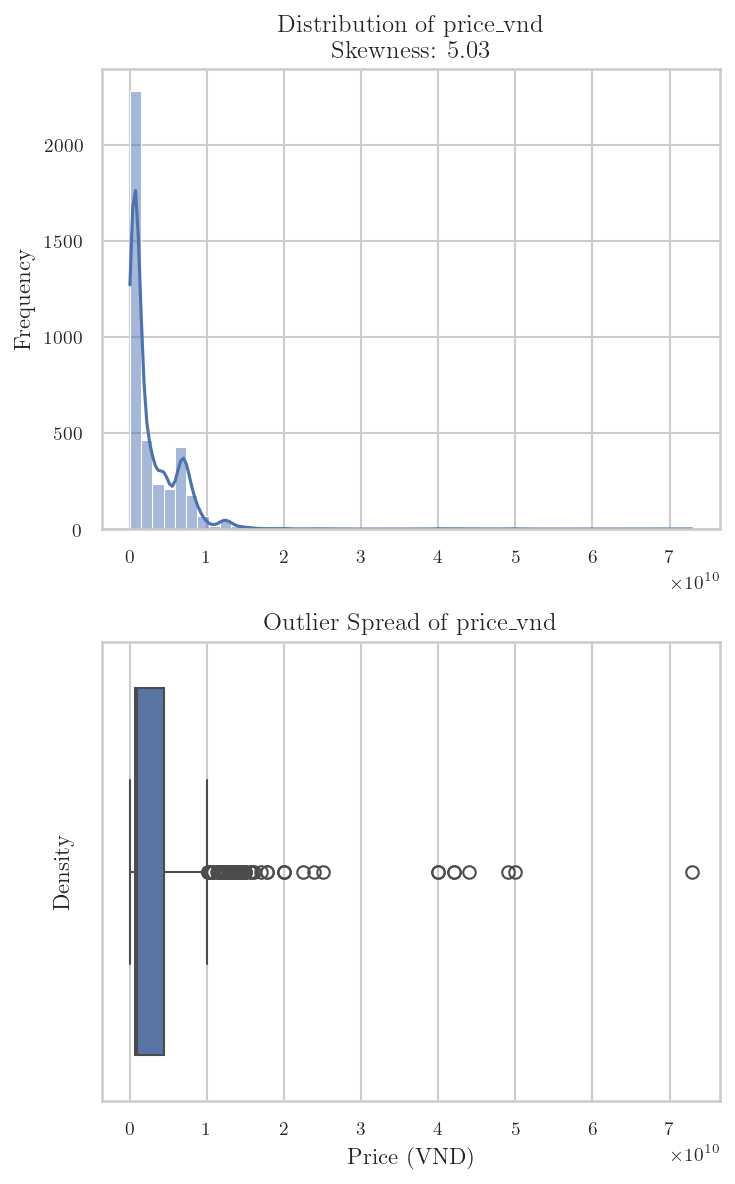


price_vnd Statistics
count           3972.000000
mean      2788254208.675730
std       3729115275.604291
min          9680000.000000
25%        613250000.000000
50%        910000000.000000
75%       4367500000.000000
max      72900000000.000000
Name: price_vnd, dtype: str


In [14]:
analyze_target_distribution(df, 'price_vnd')

We must isolate identifiers and human-readable metadata that algorithms cannot process or that cause
target leakage.

In [15]:
leakage_and_id_cols = ['id', 'seller_name', 'post_date', 'website']

In [16]:
print(f"Leakage & ID Columns Identified")
leakage_and_id_cols

Leakage & ID Columns Identified


['id', 'seller_name', 'post_date', 'website']

Phase 1 summary:
- Dataset health and sanity:
    - It has no duplicated rows or IDs
    - Missingness: The missing data matrix and health check show a very stable dataset. The highest missing rates are condition ($11.63\%$) and mileage_km ($6.74\%$).
    - Target missingness: There are exactly 2 rows missing the target variable (price_vnd at $0.05\%$).
- Target `price_vnd` integrity:
    -The skewness is 5.03. A perfectly normal distribution has a skewness of 0. The histogram and boxplot confirm a massive tail stretching to the right.
    - The median car price is 910,000,000 VND, but the maximum price is 72,900,000,000 VND. The boxplot shows severe outlier density on the high end.
    - The minimum price is 9,680,000 VND. This could be a data entry error rather than a very cheap car.

Immediate action:
- Drop the 2 rows with missing `price_vnd`
- Check the suspicuously low prices
- Check the extreme high prices

In [17]:
missing_target_count = df['price_vnd'].isna().sum()
df = df.dropna(subset=['price_vnd'])

In [18]:
suspicious_low = df[df['price_vnd'] < 50_000_000]
print(f"Found {len(suspicious_low)} records.")
if not suspicious_low.empty:
    display(suspicious_low[['id', 'brand', 'base_model', 'year', 'price_vnd', 'condition']])

Found 2 records.


,id,brand,base_model,year,price_vnd,condition
1835,1838,VinFast,VF5,2025.0,25000000.0,New
3579,3592,VinFast,Limo Green,2025.0,9680000.0,Used


In [19]:
extreme_high = df[df['price_vnd'] > 10_000_000_000]
print(f"Found {len(extreme_high)} records.")
if not extreme_high.empty:
    display(extreme_high[['id', 'brand', 'base_model', 'year', 'price_vnd', 'condition']])

Found 115 records.


,id,brand,base_model,year,price_vnd,condition
2328,2332,VinFast,VF9,2025.0,1.229000e+10,New
2359,2363,VinFast,VF9,2025.0,1.229000e+10,New
2367,2371,VinFast,VF9,2025.0,1.229000e+10,New
2370,2374,VinFast,VF9,2025.0,1.190000e+10,New
2397,2402,VinFast,VF9,2025.0,1.229000e+10,New
...,...,...,...,...,...,...
3927,3943,VinFast,VF9,2025.0,1.229000e+10,New
3933,3949,VinFast,VF9,2025.0,1.229000e+10,New
3934,3950,VinFast,VF9,2025.0,1.229000e+10,New
3952,3968,VinFast,VF9,2023.0,1.139000e+10,Used


In [20]:
median_lookup = df.groupby('base_model')['price_vnd'].transform('median')
df['price_ratio'] = df['price_vnd'] / median_lookup
anomalies = df[(df['price_ratio'] > 5) | (df['price_ratio'] < 0.2)]
print(f"Total Anomalies found: {len(anomalies)}")
display(anomalies[['id', 'brand', 'base_model', 'year', 'price_vnd', 'price_ratio']].head(20))

Total Anomalies found: 1492


,id,brand,base_model,year,price_vnd,price_ratio
26,26,VinFast,Limo Green,2025.0,6.900000e+08,0.103515
33,33,VinFast,Limo Green,2026.0,7.040000e+08,0.105615
42,42,VinFast,EC Van,2026.0,2.730000e+08,0.102632
43,43,VinFast,Limo Green,2025.0,6.900000e+08,0.103515
51,51,VinFast,EC Van,2026.0,2.730000e+08,0.102632
82,82,VinFast,Limo Green,2025.0,6.770000e+08,0.101565
83,83,VinFast,Limo Green,2025.0,6.770000e+08,0.101565
84,84,VinFast,Limo Green,2025.0,6.770000e+08,0.101565
97,97,VinFast,Limo Green,2025.0,6.900000e+08,0.103515
101,101,VinFast,Limo Green,2026.0,7.000000e+08,0.105015


It does not make sense for these regular models to be priced at 10 billion VND or 9 million VND. These are likely data entry errors where an extra zero was added or a zero was missed. We will apply a heuristic correction by dividing the price by 10 for these outliers, but only for non-luxury brands (since some luxury cars can legitimately be priced above 5 billion VND).

In [21]:
df = df.drop(columns=['price_ratio'], errors='ignore')
df = df.dropna(subset=['price_vnd']).copy()

In [22]:
luxury_brands = ['Porsche', 'Mercedes-Benz', 'Lexus', 'Audi', 'BMW', 'Volvo', 'Hongqi', 'Jaguar']
extra_zero_mask = (df['price_vnd'] >= 5_000_000_000) & (~df['brand'].isin(luxury_brands))

In [23]:
df.loc[extra_zero_mask, 'price_vnd'] = df.loc[extra_zero_mask, 'price_vnd'] / 10

In [24]:
budget_models = ['VF3', 'Mini EV', 'VF5', 'EC Van', 'Wuling']
cheap_extra_zero = (df['base_model'].isin(budget_models)) & (df['price_vnd'] > 1_000_000_000)

df.loc[cheap_extra_zero, 'price_vnd'] = df.loc[cheap_extra_zero, 'price_vnd'] / 10

In [25]:
df = df[df['price_vnd'] >= 50_000_000]

In [26]:
print(f"Current Dataset Shape: {df.shape}")
print(f"\nNew Skewness: {df['price_vnd'].skew():.2f}")
print("Cleaned Price Statistics")
print(df['price_vnd'].describe().apply(lambda x: format(x, 'f')))

Current Dataset Shape: (3970, 19)

New Skewness: 21.71
Cleaned Price Statistics
count           3970.000000
mean       836377100.676322
std       2047290553.350408
min         50000000.000000
25%        415000000.000000
50%        650000000.000000
75%        790000000.000000
max      72900000000.000000
Name: price_vnd, dtype: str


In [27]:
df = df[df['price_vnd'] < 20_000_000_000]
print(f"Extreme outliers removed. New Skewness: {df['price_vnd'].skew():.2f}")

Extreme outliers removed. New Skewness: 7.27


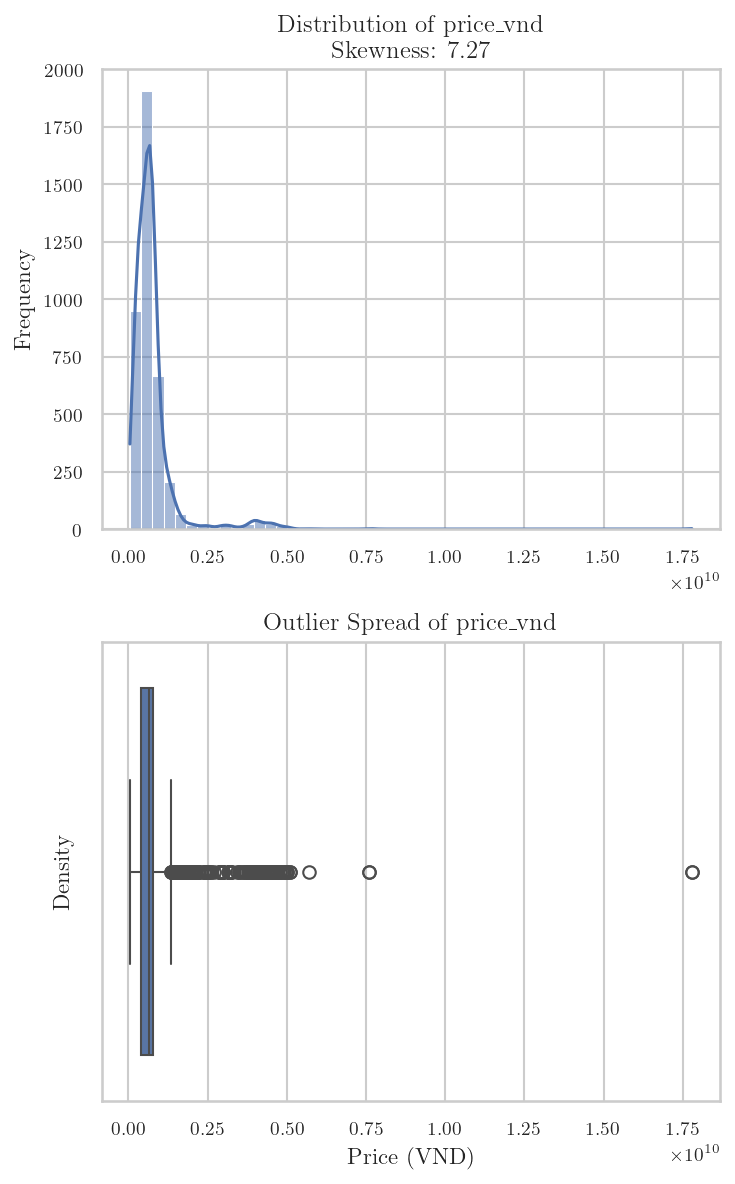


price_vnd Statistics
count           3963.000000
mean       761334112.966187
std        816243963.369881
min         50000000.000000
25%        415000000.000000
50%        650000000.000000
75%        789000000.000000
max      17790000000.000000
Name: price_vnd, dtype: str


In [28]:
analyze_target_distribution(df, 'price_vnd')

Phase 1 summary (after cleaning): The target is now clean, but still heavily right-skewed.

## Phase 1.3: Univariate Analysis & Distributions

Flow: Distributions → Outliers

* 1. Numerical Distributions:
* Action: Plot histograms with KDE (Kernel Density Estimate) for `mileage_km` and `year`.
* Model Check: If `mileage_km` has a massive tail (e.g., most cars are < 50k km, but a few are 300k km), SVM and Linear Regression will be severely distorted.
* Phase 2 Backlog: Note which features need scaling (StandardScaler or RobustScaler) and capping (using the IQR method to squash extreme outliers).


* 2. Categorical Cardinality:
* Action: Plot bar charts for `base_model`, `brand`, `city`, `body_type`. Count the unique values.
* Model Check: If `base_model` has 50 unique categories, One-Hot Encoding it will create 50 sparse columns. This dilutes Linear Regression and makes trees in Random Forest very unbalanced.
* Phase 2 Backlog: If a category has a "long tail" of rare values (e.g., cities with only 2 cars), plan to group them into an "Other" bucket.



Numerical feature distribution

In [29]:
REPORT_FIGSIZE = FIGSIZE_SINGLE

In [30]:
UNIVARIATE_PATH = REPORT_EDA / "univariate_analysis"

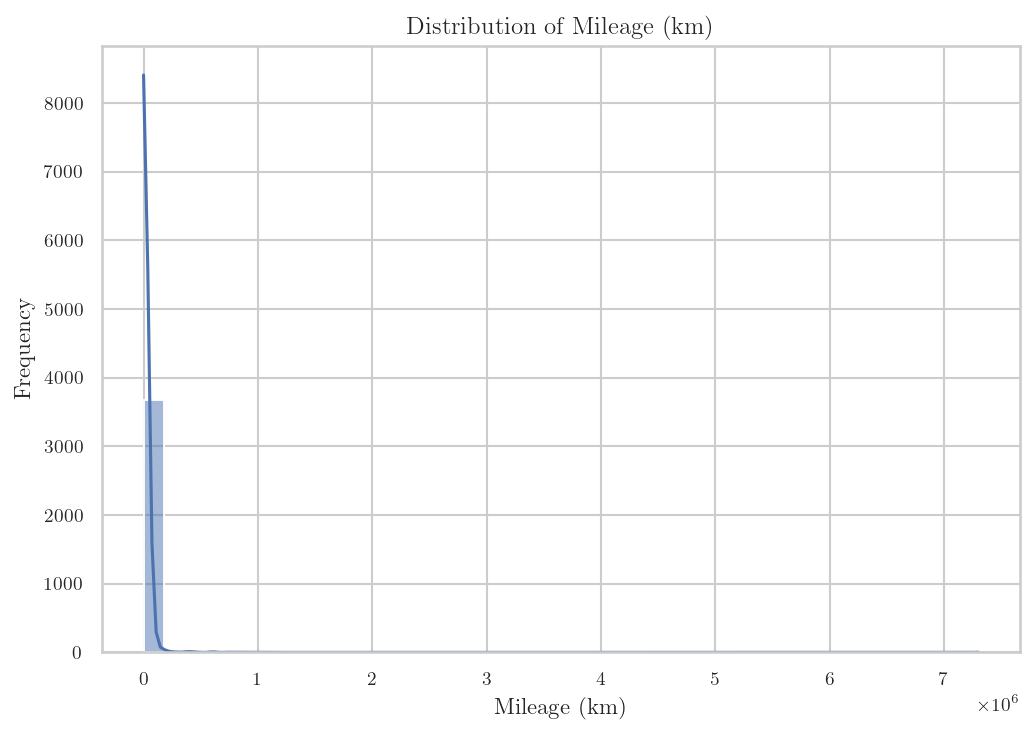

In [31]:
plt.figure(figsize=REPORT_FIGSIZE)
sns.histplot(df['mileage_km'].dropna(), kde=True, bins=40)
plt.title('Distribution of Mileage (km)')
plt.xlabel('Mileage (km)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'mileage_distribution.pdf', bbox_inches='tight', format='pdf')
plt.show()

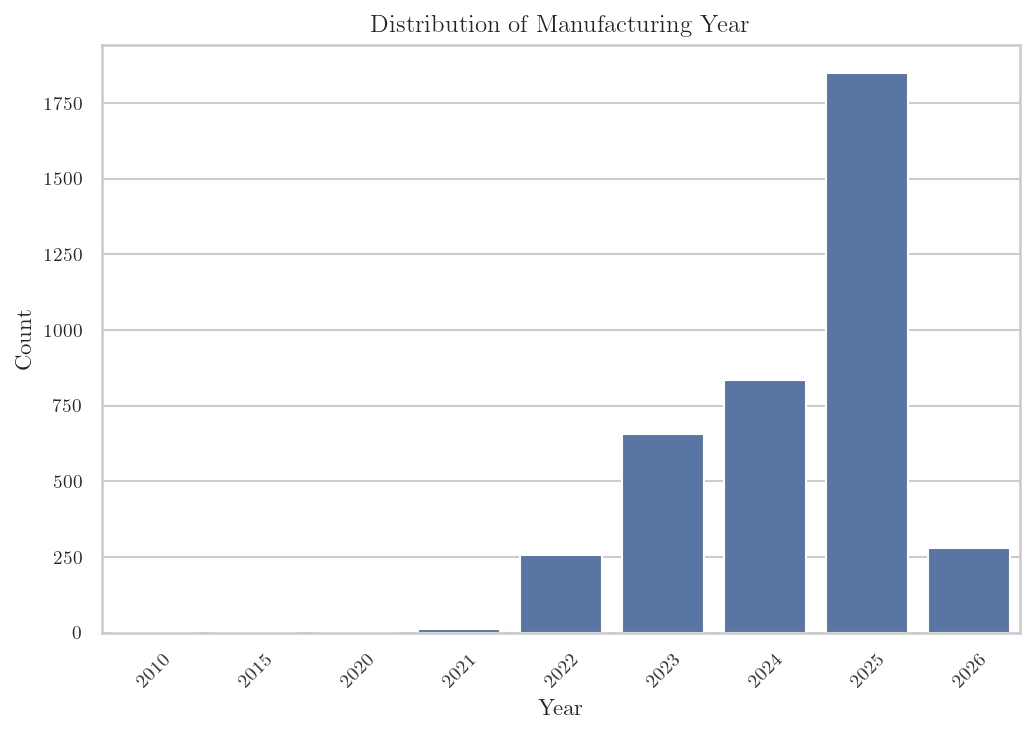

In [32]:
plt.figure(figsize=REPORT_FIGSIZE)
sns.countplot(x=df['year'].dropna().astype(int))
plt.title('Distribution of Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'year_distribution.pdf', bbox_inches='tight', format='pdf')
plt.show()

Categorical feature distribution and cardinality

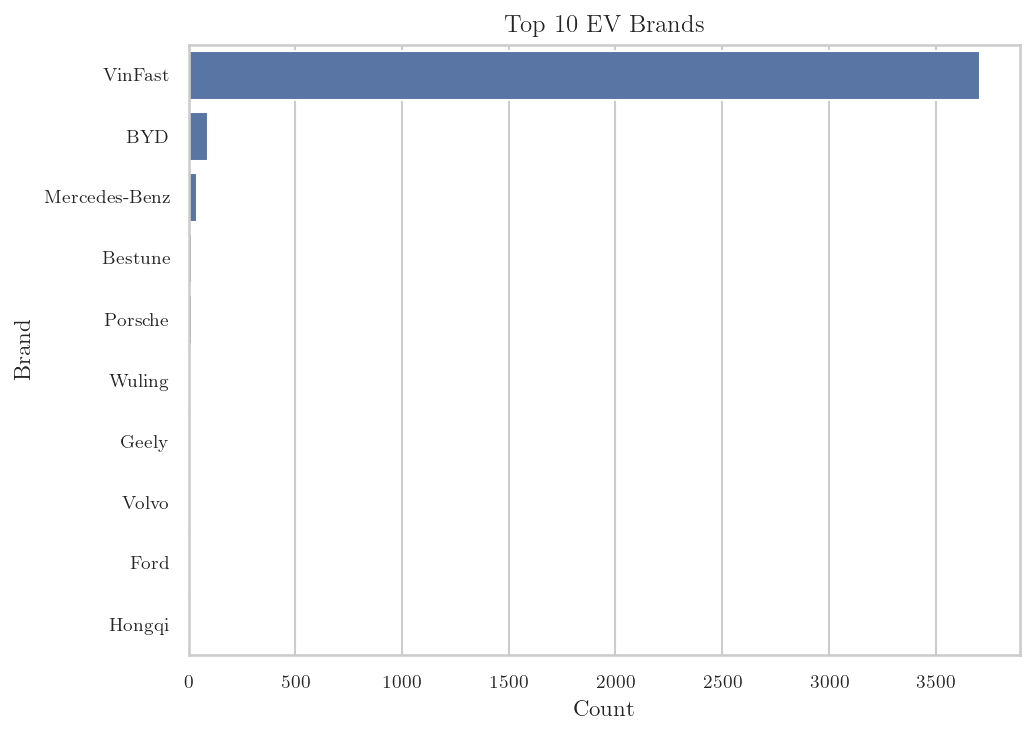

In [33]:
# --- 3. Top 10 Brands ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.countplot(y=df['brand'], order=df['brand'].value_counts().index[:10])
plt.title('Top 10 EV Brands')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'brand_count.pdf', bbox_inches='tight', format='pdf')
plt.show()

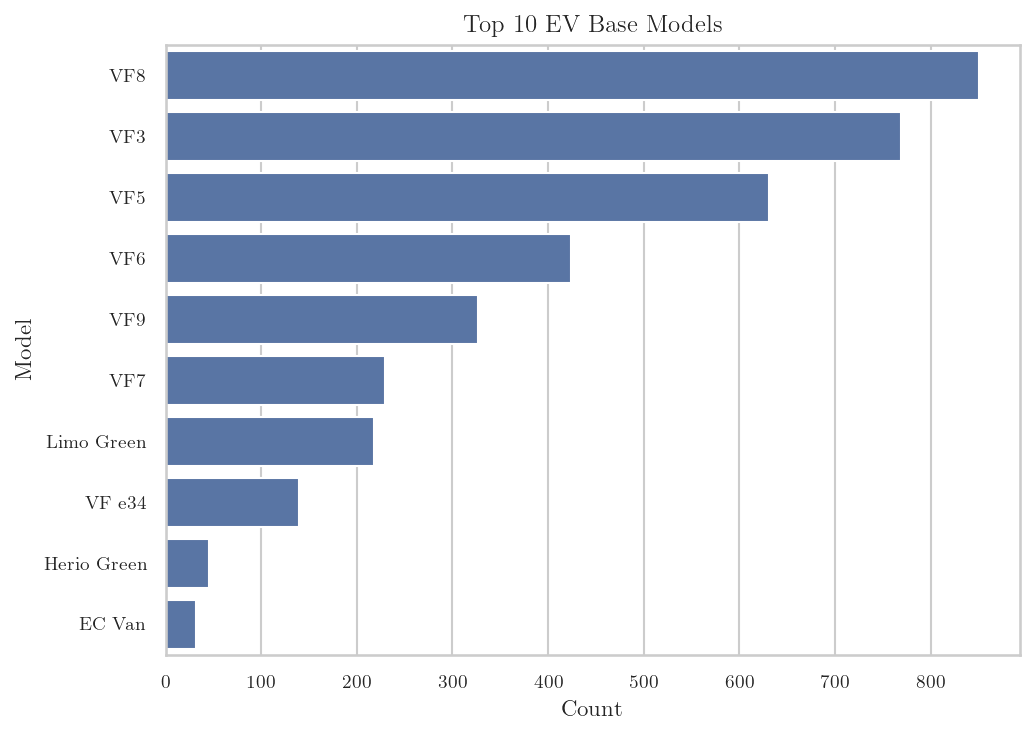

In [34]:
# --- 4. Top 10 Models ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.countplot(y=df['base_model'], order=df['base_model'].value_counts().index[:10])
plt.title('Top 10 EV Base Models')
plt.xlabel('Count')
plt.ylabel('Model')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'model_count.pdf', bbox_inches='tight', format='pdf')
plt.show()

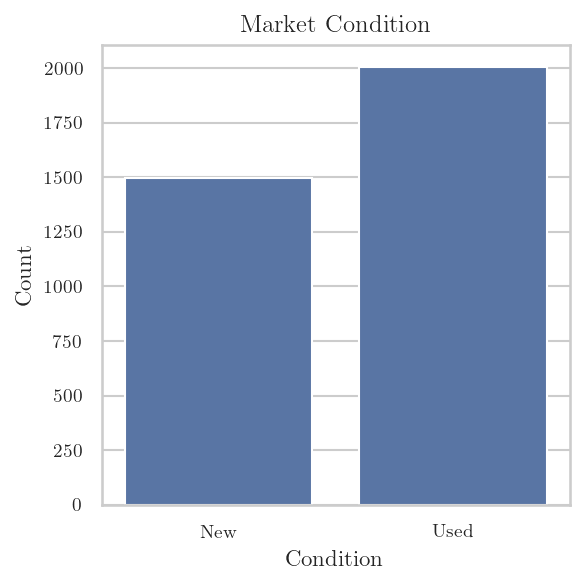

In [35]:
# --- 5. Market Condition ---
plt.figure(figsize=(4, 4))
sns.countplot(x=df['condition'], order=['New', 'Used'])
plt.title('Market Condition')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'condition_count.pdf', bbox_inches='tight', format='pdf')
plt.show()

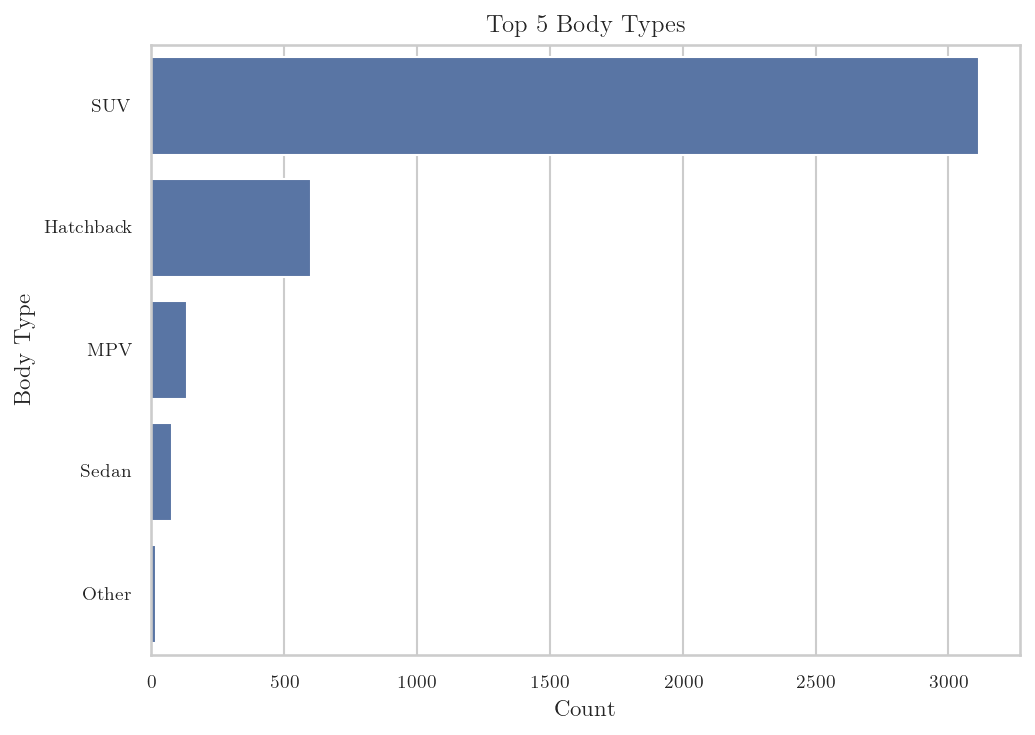

In [36]:
# --- 6. Top 5 Body Types ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.countplot(y=df['body_type'], order=df['body_type'].value_counts().index[:5])
plt.title('Top 5 Body Types')
plt.xlabel('Count')
plt.ylabel('Body Type')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'body_type_count.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [37]:
print("\n")
extract_plot_stats(df, ['mileage_km', 'year', 'brand', 'base_model', 'condition', 'body_type'])



Plot data extraction

Feature: mileage_km
count       3695.000000
mean       19819.965088
std       126167.000619
min            0.000000
25%            0.000000
50%         2600.000000
75%        27750.000000
max      7300000.000000
Skewness: 52.33

Feature: year
count    3896.000000
mean     2024.298768
std         1.112450
min      2010.000000
25%      2024.000000
50%      2025.000000
75%      2025.000000
max      2026.000000
Skewness: -1.45

Feature: brand
brand
VinFast          3710
BYD                90
Mercedes-Benz      39
NaN                27
Bestune            17
Porsche            17
Wuling             12
Geely              10
Volvo               9
Ford                8

Feature: base_model
base_model
VF8            851
VF3            769
VF5            631
VF6            424
VF9            327
VF7            229
Limo Green     218
VF e34         140
Herio Green     45
EC Van          32

Feature: condition
condition
Used    2006
New     1495
NaN      462

Feature: body_t

Phase 3 summary:

1. Market Composition & Distribution

- The VinFast Monopoly: The dataset is heavily monopolized by a single manufacturer. VinFast accounts for 3,710 out of the 3,963 listings, representing over 93% of the market. The volume is driven primarily by the VF8 , VF3 , and VF5  models.
- Body Type Preference: The market is overwhelmingly skewed toward SUVs , with 3,114 listings compared to just 600 Hatchbacks.
- Age of Fleet: The EV market in this dataset is extremely nascent. The vast majority of listings are concentrated in the manufacturing years 2024 and 2025, resulting in a left-skewed distribution (Skewness: -1.45).
- Condition Balance: There is a healthy distribution between Used (2,006) and New (1,495)  vehicles, providing a solid foundation for the models to learn depreciation curves.

2. The Mileage Anomaly
The `mileage_km` feature contains severe structural issues that must be addressed:
- Catastrophic Outliers: The maximum mileage is recorded as 7,300,000 km. The plot visualizes this extreme tail extending past $7 \times 10^6$. This is a physical impossibility for a passenger vehicle and indicates a data entry error (likely sellers typing arbitrary numbers).
- Extreme Skewness: These outliers drive the skewness to an unusable 52.33. Tree-based models can handle mild skewness, but linear algorithms will collapse under this variance.

3. Action Items Added to Phase 2 Backlog
- Mileage Capping: We must apply an Interquartile Range (IQR) cap or a hard domain-knowledge limit (e.g., capping mileage at 200,000 km) to drop or squash the impossible $7.3 \times 10^6$ outliers.
- Smart Imputation: There are 462 missing values in the `condition` column. Instead of dropping them or filling with the mode, we can use a deterministic rule: If `mileage_km` is 0 or extremely low, impute as 'New'; otherwise, impute as 'Used'.
- Stratified Train-Test Split: Because minority brands like BYD, Mercedes-Benz, and Porsche have very few listings, a standard random split might place all of them in the training set and none in the test set. We must use `stratify=df['brand']` or group rare brands into an 'Other' category before splitting.


## Phase 1.4: Bivariate Analysis

Flow: Relationships (Features vs. Target)

* 1. Numerical vs. Price:
* Action: Scatter plots of `mileage_km` vs. `price_vnd` and `year` vs. `price_vnd`. Plot a regression line through them.
* Model Check: Is the relationship linear? If depreciation curves heavily (e.g., drops fast in year 1, then flattens), Linear Regression will underfit.


* 2. Categorical vs. Price:
* Action: Boxplots of `brand` vs. `price_vnd` and `condition` (New/Used) vs. `price_vnd`.
* Model Check: This proves to your stakeholders which features hold the most predictive weight. If the boxplots for "New" vs. "Used" are perfectly separated, it guarantees this feature will be selected in Phase 4.


In [38]:
BIVARIATE_PATH = REPORT_EDA / "bivariate_analysis"

os.makedirs(BIVARIATE_PATH, exist_ok=True)

In [39]:
# --- Utility for Bivariate Stats Extraction ---
def extract_bivariate_stats(dataframe: pd.DataFrame, target: str, num_cols: list, cat_cols: list) -> None:
    print("BIVARIATE STATS EXTRACTION")
    print(f"Target Variable: {target}\n")

    print("Numerical Correlations (Pearson)")
    for col in num_cols:
        corr = dataframe[[col, target]].corr().iloc[0, 1]
        print(f"{col} vs {target}: {corr:.4f}")

    print("\nCategorical Medians")
    for col in cat_cols:
        top_cats = dataframe[col].value_counts().nlargest(10).index
        stats = (dataframe[dataframe[col].isin(top_cats)]
                 .groupby(col)[target]
                 .median()
                 .sort_values(ascending=False))
        print(f"\nMedian {target} by {col} (Top 10):")
        print(stats.apply(lambda x: format(x, '.2f')).to_string())

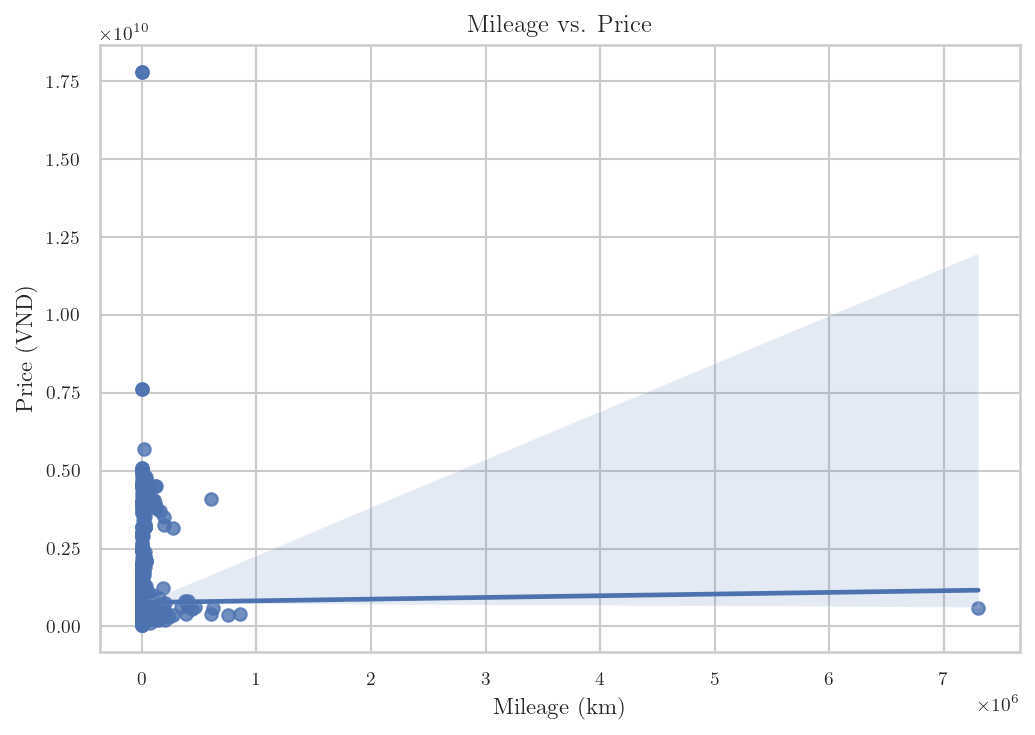

In [40]:
# --- 1. Mileage vs Price (Scatter + Regression) ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.regplot(data=df, x='mileage_km', y='price_vnd')
plt.title('Mileage vs. Price')
plt.xlabel('Mileage (km)')
plt.ylabel('Price (VND)')
plt.tight_layout()
plt.savefig(BIVARIATE_PATH / 'scatter_mileage_price.pdf', bbox_inches='tight', format='pdf')
plt.show()

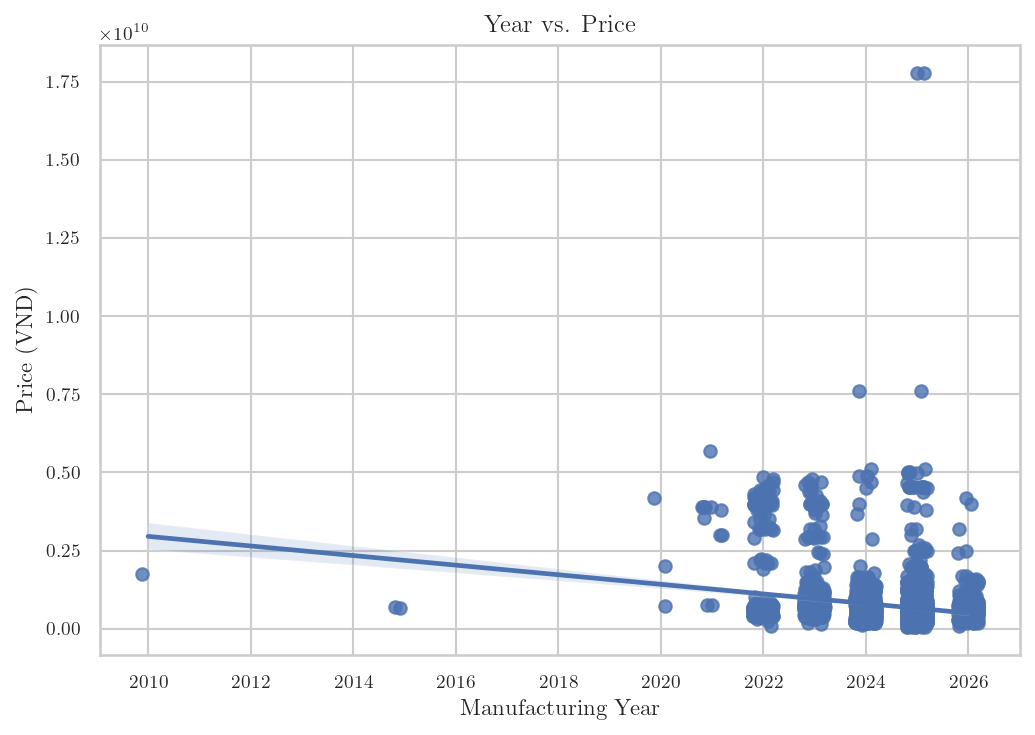

In [41]:
# --- 2. Year vs Price (Scatter + Regression) ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.regplot(data=df, x='year', y='price_vnd', x_jitter=0.2)
plt.title('Year vs. Price')
plt.xlabel('Manufacturing Year')
plt.ylabel('Price (VND)')
plt.tight_layout()
plt.savefig(BIVARIATE_PATH / 'scatter_year_price.pdf', bbox_inches='tight', format='pdf')
plt.show()

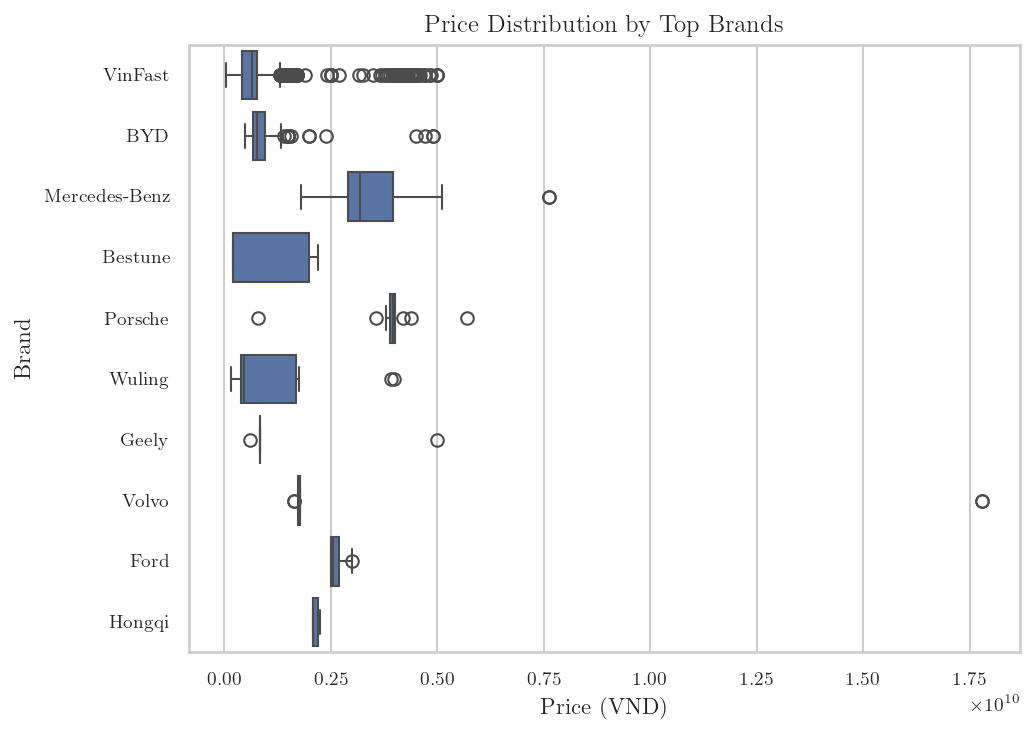

In [42]:
# --- 3. Brand vs Price (Boxplot) ---
plt.figure(figsize=REPORT_FIGSIZE)
top_brands = df['brand'].value_counts().nlargest(10).index
sns.boxplot(data=df[df['brand'].isin(top_brands)], y='brand', x='price_vnd', order=top_brands)
plt.title('Price Distribution by Top Brands')
plt.xlabel('Price (VND)')
plt.ylabel('Brand')
plt.tight_layout()
plt.savefig(BIVARIATE_PATH / 'box_brand_price.pdf', bbox_inches='tight', format='pdf')
plt.show()

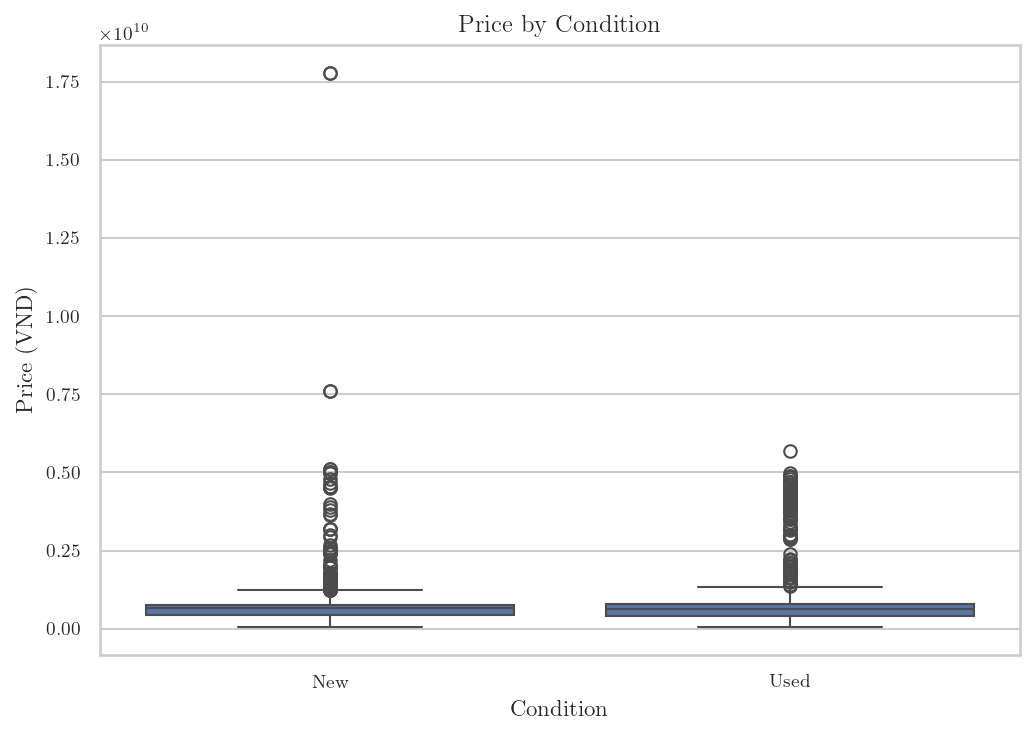

In [43]:
# --- 4. Condition vs Price (Boxplot) ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.boxplot(data=df, x='condition', y='price_vnd', order=['New', 'Used'])
plt.title('Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Price (VND)')
plt.tight_layout()
plt.savefig(BIVARIATE_PATH / 'box_condition_price.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [44]:
# --- 5. Extract Data ---
print("\n")
extract_bivariate_stats(df, 'price_vnd', ['mileage_km', 'year'], ['brand', 'condition'])



BIVARIATE STATS EXTRACTION
Target Variable: price_vnd

Numerical Correlations (Pearson)
mileage_km vs price_vnd: 0.0081
year vs price_vnd: -0.2075

Categorical Medians

Median price_vnd by brand (Top 10):
brand
Porsche          3950000000.00
Mercedes-Benz    3179000000.00
Ford             2549000000.00
Hongqi           2090000000.00
Volvo            1779000000.00
Geely             840000000.00
BYD               756000000.00
VinFast           639000000.00
Wuling            471500000.00
Bestune           205000000.00

Median price_vnd by condition (Top 10):
condition
New     669000000.00
Used    635000000.00


Phase 4 summary:
- Feature vs price:
    - The Broken Mileage Correlation: The Pearson correlation between mileage_km and price_vnd is practically zero (0.0081). Looking at the scatter plot , we can definitively see why: the extreme outlier at 7.3 million km forces the entire dataset into a tight vertical line at the left axis. The regression line is completely flattened by the gravitational pull of this single error. This visually proves why algorithms like Linear Regression cannot be trained on raw data.
    - Year vs price: The Year vs. Price Illusion: The correlation between year and price is actually negative (-0.2075), meaning newer cars appear to be cheaper. The scatter plot reveals the cause of this paradox : the pre-2022 market consisted almost entirely of expensive luxury imports, while the massive explosion of cars in 2024-2025 is driven by budget-friendly VinFast models. The model year is heavily confounded by the car brand. Tree models (Random Forest, XGBoost) will easily understand this interaction, but linear models will struggle.
- Categorical:
    - Brand as the Ultimate Predictor: The boxplot for Brand vs. Price  proves that brand is the strongest predictor of value in this dataset. There is absolute separation between the luxury tier (Porsche at a 3.95 Billion VND median , Mercedes at 3.17 Billion ) and the budget tier (VinFast at 639 Million , Wuling at 471 Million ).
    - Condition & Depreciation: Interestingly, the median price difference between 'New' (669 Million VND) and 'Used' (635 Million VND)  is only 34 Million VND (roughly 5%). The boxplots for condition are nearly identical , aside from a massive luxury outlier in the 'New' category. This suggests that EVs in the Vietnamese secondary market hold their value exceptionally well, or that the market is so young that "Used" cars are only a few months old.

### Phase 1.5: Multivariate Analysis

Flow: Relationships (Feature vs. Feature)

* 1. The Correlation Matrix:
* Action: Generate a Pearson Correlation Heatmap for all numerical variables.
* Model Check (CRITICAL for Linear Regression): Look for Multicollinearity. For example, if you create `car_age` from `year`, they will have a correlation of -1.0. If `seats` and `doors` have a correlation of 0.95, keeping both will cause the coefficients of your Linear Regression and SVM to become unstable and meaningless.
* Phase 2 Backlog: Plan to drop one of the highly correlated pairs.


* 2. Interaction Effects:
* Action: Scatter plot of `mileage_km` vs. `price_vnd`, color-coded (hue) by `condition`.
* Model Check: Tree models (RF, XGBoost) catch interaction effects naturally. Linear models do not. If you see a strong interaction, you might need to artificially create an interaction feature (e.g., `mileage * is_used`) for your Linear Regression to perform well.


In [45]:
MULTIVARIATE_PATH = REPORT_EDA / "multivariate_analysis"

os.makedirs(MULTIVARIATE_PATH, exist_ok=True)

In [46]:
# 1. Select only numerical columns, explicitly excluding 'id' (Leakage)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'id' in num_cols:
    num_cols.remove('id')

In [47]:
# --- 1. Correlation Heatmap ---
# Slightly larger figsize to ensure the text annotations fit well in the report
plt.figure(figsize=(6, 5))
corr_matrix = df[num_cols].corr()

<Figure size 900x750 with 0 Axes>

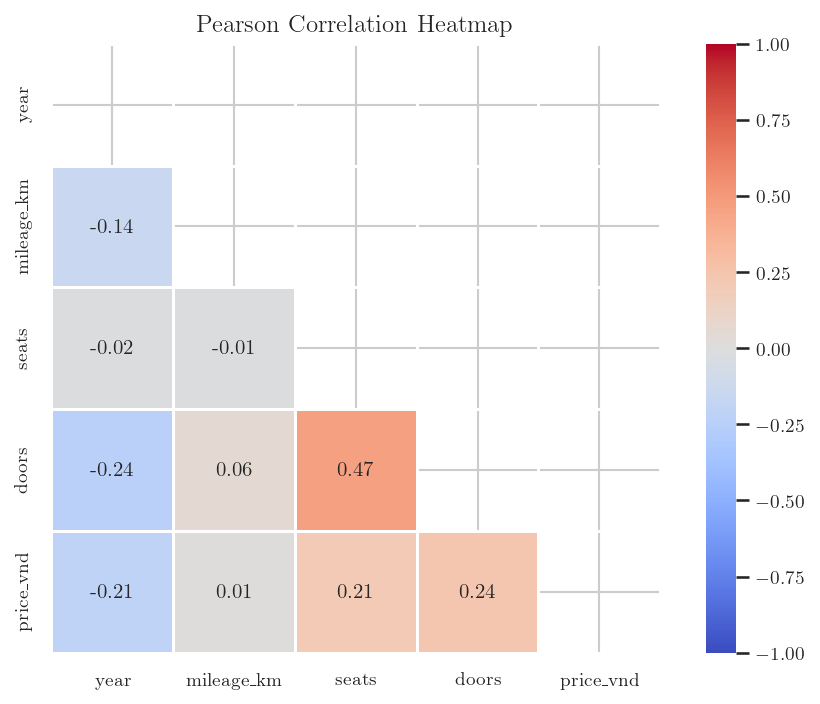

In [48]:
# Generate a mask for the upper triangle to make it clean and professional
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5,
            annot_kws={"size": 10})
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.savefig(MULTIVARIATE_PATH / 'correlation_heatmap.pdf', bbox_inches='tight', format='pdf')
plt.show()

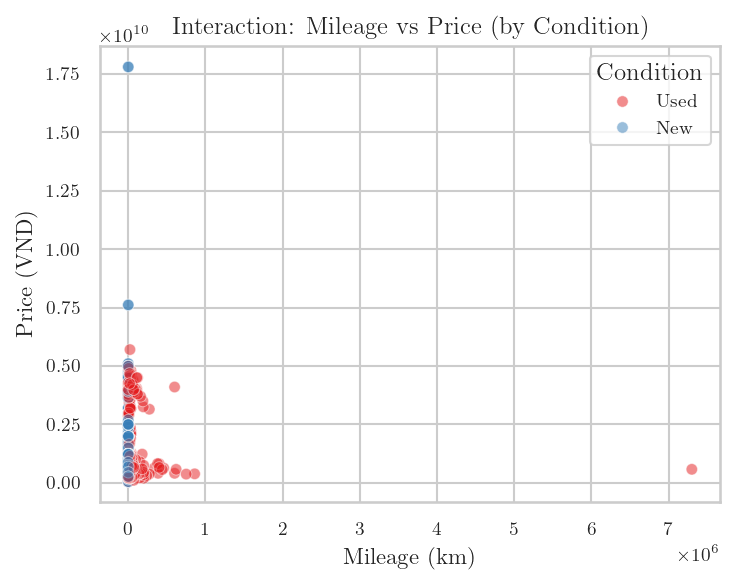

In [49]:
# --- 2. Interaction Effects (Mileage vs. Price by Condition) ---
plt.figure(figsize=(5, 4))
# We use scatterplot here to clearly see the color separation
sns.scatterplot(data=df, x='mileage_km', y='price_vnd', hue='condition',
                alpha=0.5, palette='Set1', s=30)
plt.title('Interaction: Mileage vs Price (by Condition)')
plt.xlabel('Mileage (km)')
plt.ylabel('Price (VND)')
plt.legend(title='Condition')
plt.tight_layout()
plt.savefig(MULTIVARIATE_PATH / 'interaction_mileage_condition.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [50]:
print("Multivariate stats extraction")
print("Highly Correlated Feature Pairs (|corr| > 0.5):")

corr_pairs = corr_matrix.unstack().sort_values(kind="quicksort", ascending=False)
corr_pairs = corr_pairs[corr_pairs != 1.0].drop_duplicates()

high_corr = corr_pairs[abs(corr_pairs) > 0.5]

if high_corr.empty:
    print("No strongly correlated feature pairs found (No Multicollinearity threat).")
else:
    for index, value in high_corr.items():
        print(f" {index[0]} <-> {index[1]}: {value:.4f}")


Multivariate stats extraction
Highly Correlated Feature Pairs (|corr| > 0.5):
No strongly correlated feature pairs found (No Multicollinearity threat).


Phase 1.5 summary:

1. No Multicollinearity Threat (Green Light for Linear Models)

* The Heatmap Findings: The Pearson correlation heatmap confirms that there is no severe multicollinearity among our numerical predictors. The highest correlation between any two independent variables is between `seats` and `doors` at 0.47.
* Model Implication: Because no pair exceeds the 0.50 threshold, we do not need to drop any numerical columns for redundancy. Your Linear Regression and SVM models will be able to calculate stable, independent coefficients for these features.

2. Interaction Effects (Mileage, Condition, and Price)

* Logical Boundaries: The hue-coded scatter plot of Mileage vs. Price reveals a strict logical boundary. "New" vehicles (blue dots) are exclusively clustered at or near zero mileage, stretching vertically across different price points.
* The Outlier's Impact on "Used" Cars: "Used" vehicles (red dots) naturally account for all the mileage spread. However, because that massive $7.3 \times 10^6$ km outlier belongs to the "Used" category, it stretches the x-axis so severely that the natural depreciation curve (how fast price drops per km driven) is completely unreadable.
* Model Implication: Because "New" cars do not have a varying mileage slope, we don't necessarily need to engineer a complex mathematical interaction feature (like `mileage * is_used`). Tree-based models (XGBoost, Random Forest) will easily split the data logically: `if condition == 'New' -> ignore mileage`.

In [51]:
CHECKPOINT_PATH = INTERIM_DATA / "checkpoints"
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)

In [52]:
checkpoint_path = CHECKPOINT_PATH / 'ev_phase1_cleaned.csv'
df.to_csv(checkpoint_path, index=False, encoding='utf-8-sig')